#### Biggest predictor of CO₂ output

**What is the biggest predictor of a large CO₂ output per capita of a country?**

To determine this you may want to consider things like GDP per capita, diets, number of cars per capita, various energy source, mobility and other factors.

Your answer can also be a specific combination of certain factors. Anyway, remember to include the explanations in your report.

In [198]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

In [199]:
# Import the original Kaya Identity CO2 data
# df_original_data = pd.read_csv('https://raw.githubusercontent.com/majavanput/co2-emissions/main/data/kaya-identity-co2.csv')
df_original_data = pd.read_csv('../data/kaya-identity-co2.csv')

In [200]:
# Print information about the DataFrame
df_original_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17064 entries, 0 to 17063
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Entity                           17064 non-null  str    
 1   Code                             15810 non-null  str    
 2   Year                             17064 non-null  int64  
 3   CO₂ emissions                    14350 non-null  float64
 4   Energy intensity (Energy / GDP)  7882 non-null   float64
 5   GDP per capita                   9671 non-null   float64
 6   Population                       15412 non-null  float64
 7   Carbon intensity (CO₂ / energy)  10511 non-null  float64
 8   Carbon intensity (CO₂ / $)       10122 non-null  float64
 9   GDP per capita (Annotations)     13 non-null     str    
dtypes: float64(6), int64(1), str(3)
memory usage: 1.3 MB


In [201]:
# Overview of missing values per column
for name, values in df_original_data.items():
  print(f'Missing values in column {name}: ', df_original_data[name].isnull().sum())

# Total number of missing values in dataset
total_nan = df_original_data.isnull().sum().sum()
print(f"Total number of NaN values in the DataFrame: {total_nan}")

Missing values in column Entity:  0
Missing values in column Code:  1254
Missing values in column Year:  0
Missing values in column CO₂ emissions:  2714
Missing values in column Energy intensity (Energy / GDP):  9182
Missing values in column GDP per capita:  7393
Missing values in column Population:  1652
Missing values in column Carbon intensity (CO₂ / energy):  6553
Missing values in column Carbon intensity (CO₂ / $):  6942
Missing values in column GDP per capita (Annotations):  17051
Total number of NaN values in the DataFrame: 52741


In [202]:
df_co2_kaya = df_original_data.copy()

# Drop unnecessary columns
df_co2_kaya.drop(columns=['Code', 'Carbon intensity (CO₂ / $)', 'GDP per capita (Annotations)'], inplace=True)

# Rename columns
df_co2_kaya.rename(columns={'Energy intensity (Energy / GDP)': 'Energy intensity',
                             'Carbon intensity (CO₂ / energy)': 'Carbon intensity',
                             'CO₂ emissions': 'CO2 emissions'}, inplace=True)

In [203]:
df_co2_kaya.head()

,Entity,Year,CO2 emissions,Energy intensity,GDP per capita,Population,Carbon intensity
0,Afghanistan,1965,1006917.0,NaN,1290.0,10036003.0,NaN
1,Afghanistan,1966,1091159.0,NaN,1272.0,10266397.0,NaN
2,Afghanistan,1967,1281865.0,NaN,1277.0,10505961.0,NaN
3,Afghanistan,1968,1223391.0,NaN,1290.0,10756924.0,NaN
4,Afghanistan,1969,941232.0,NaN,1278.0,11017417.0,NaN


### World only

In [204]:
# Columns to analyze for correlation with CO2 emissions
correlation_columns = ['Energy intensity', 'GDP per capita', 'Population', 'Carbon intensity']

# Check correlation for World data only
df_world = df_co2_kaya[df_co2_kaya['Entity'] == 'World']

filtered_dfs_world = {}

for corr in correlation_columns:
    df_filtered = df_world[['CO2 emissions', corr]].dropna()

    # Save the filtered dataframe
    filtered_dfs_world[corr] = df_filtered

    pearson_corr, p_value = pearsonr(df_filtered['CO2 emissions'], df_filtered[corr])
    spearman_corr = df_filtered.corr(method = 'spearman', numeric_only=True)

    print(f"{corr}")
    print(f"Pearson: {pearson_corr} (p = {p_value})")
    print(f"Spearman: {spearman_corr}")
    print("\n")

Energy intensity
Pearson: -0.9904820844191181 (p = 7.964302889081881e-11)
Spearman:                   CO2 emissions  Energy intensity
CO2 emissions          1.000000         -0.901099
Energy intensity      -0.901099          1.000000


GDP per capita
Pearson: 0.9906884015291025 (p = 7.062722392663448e-11)
Spearman:                 CO2 emissions  GDP per capita
CO2 emissions        1.000000        0.956044
GDP per capita       0.956044        1.000000


Population
Pearson: 0.9879547034457486 (p = 6.840123768015849e-48)
Spearman:                CO2 emissions  Population
CO2 emissions       1.000000    0.995207
Population          0.995207    1.000000


Carbon intensity
Pearson: -0.8054911168105277 (p = 8.491145999063692e-15)
Spearman:                   CO2 emissions  Carbon intensity
CO2 emissions          1.000000         -0.846624
Carbon intensity      -0.846624          1.000000




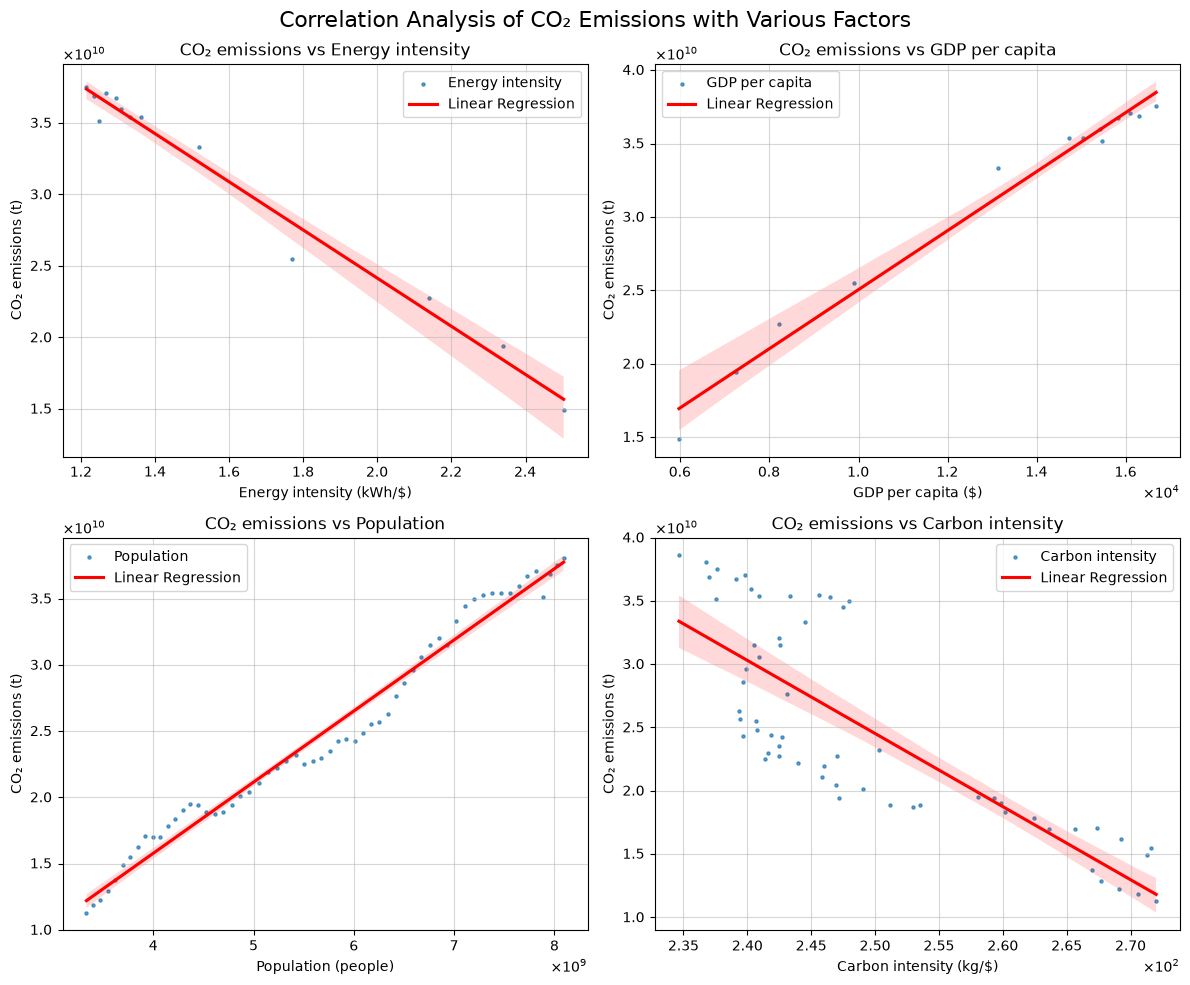

In [205]:
# Select the relevant columns for correlation analysis
correlation_columns = ['Energy intensity', 'GDP per capita', 'Population', 'Carbon intensity']

# Units: https://ourworldindata.org/grapher/kaya-identity-co2?overlay=sources
xaxis = ['Energy intensity (kWh/$)', 'GDP per capita ($)', 'Population (people)', 'Carbon intensity (kg/$)']

# Create a figure and axis object for plotting the correlations
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# To access in for loop, flatten the axes array
axes = axes.flatten()

for i, corr in enumerate(correlation_columns):
    # Add a regression line with scatter points
    sns.regplot(data=filtered_dfs_world[corr], x=corr, y='CO2 emissions', ax=axes[i], scatter=True, label=corr,
        scatter_kws={'color': 'tab:blue', 'alpha': 0.7, 's': 5}, line_kws={'color': 'red', 'label': 'Linear Regression'})

    # Set title, labels, legend, grid
    axes[i].set_title(f'CO₂ emissions vs {corr}')
    axes[i].set_xlabel(xaxis[i])
    axes[i].set_ylabel('CO₂ emissions (t)')
    axes[i].legend()
    axes[i].grid(alpha=0.5)

    # Use a mathematical expression for large numbers
    axes[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0), useMathText=True)

fig.suptitle('Correlation Analysis of CO₂ Emissions with Various Factors', fontsize=16)
plt.tight_layout()
plt.show()

**What is the biggest predictor of a large CO₂ output per capita of a country?**

##### World only analysis
If we exclude individual countries and regions and look only at the World data over time, we see very strong correlations for all four factors. 

Population has still the strongest (and even higher) positive Pearson correlation with CO₂ emissions (0.995207), followed by GDP per capita (0.956044). These results suggest that a rising population and GDP per capita are strongly associated with increasing global CO₂ emissions over time. Energy intensity (-0.901099) and Carbon intensity (-0.846624) show a negative strong association in the World only data.

##### Initial analysis (see extra)

Population is the biggest predictor of a large CO₂ output, as it has the highest correlation coefficient with CO₂ emissions (0.798097). GDP per capita also has a strong association (0.649642). However, this dataset includes a mixture of all available entities, including countries, continents, income groups, historical countries and regions, etcetera. Therefore, using world data only makes more sense.

### EXTRA: Initial analysis (all entities)

Again, this dataset includes a mixture of all available entities, including countries, continents, income groups, historical countries and regions, etcetera. Therefore, using world data only makes more sense.

In [206]:
# Columns to analyze for correlation with CO2 emissions
correlation_columns = ['Energy intensity', 'GDP per capita', 'Population', 'Carbon intensity']

filtered_dfs = {}

df_all = df_co2_kaya.copy()

for corr in correlation_columns:
    df_filtered = df_all[['CO2 emissions', corr]].dropna()

    # Save the filtered dataframe
    filtered_dfs[corr] = df_filtered

    pearson_corr, p_value = pearsonr(df_filtered['CO2 emissions'], df_filtered[corr])
    spearman_corr = df_filtered.corr(method = 'spearman', numeric_only=True)

    print(f"{corr}")
    print(f"Pearson: {pearson_corr} (p = {p_value})")
    print(f"Spearman: {spearman_corr}")
    print("\n")

Energy intensity
Pearson: 0.02993682305286375 (p = 0.008289498195630218)
Spearman:                   CO2 emissions  Energy intensity
CO2 emissions          1.000000          0.491567
Energy intensity       0.491567          1.000000


GDP per capita
Pearson: 0.08633863279915378 (p = 1.1045257674075717e-16)
Spearman:                 CO2 emissions  GDP per capita
CO2 emissions        1.000000        0.649642
GDP per capita       0.649642        1.000000


Population
Pearson: 0.8947991302094506 (p = 0.0)
Spearman:                CO2 emissions  Population
CO2 emissions       1.000000    0.798097
Population          0.798097    1.000000


Carbon intensity
Pearson: -0.00018410603240244625 (p = 0.9849425070847573)
Spearman:                   CO2 emissions  Carbon intensity
CO2 emissions           1.00000           0.18281
Carbon intensity        0.18281           1.00000




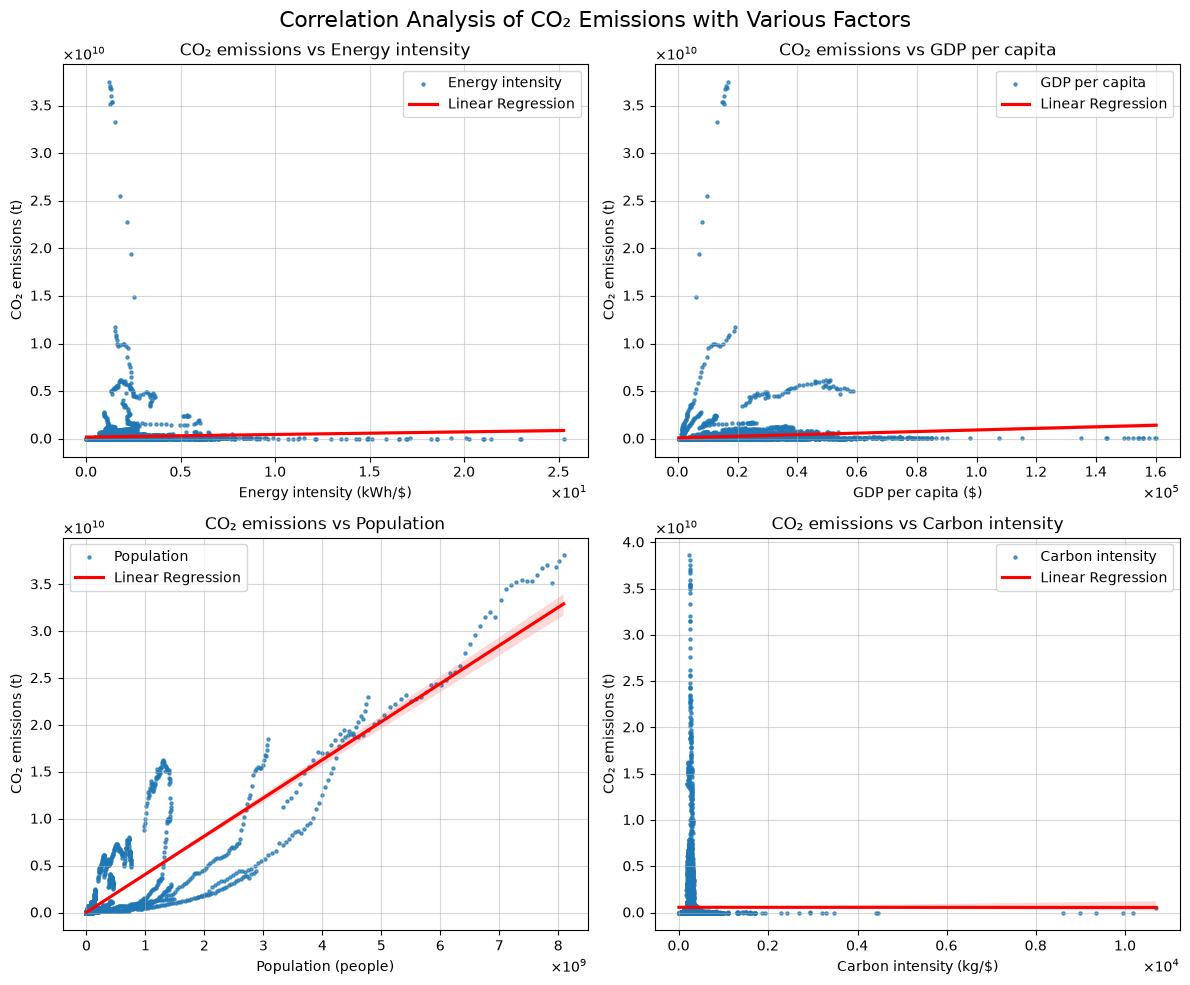

In [207]:
# Select the relevant columns for correlation analysis
correlation_columns = ['Energy intensity', 'GDP per capita', 'Population', 'Carbon intensity']

# Units: https://ourworldindata.org/grapher/kaya-identity-co2?overlay=sources
xaxis = ['Energy intensity (kWh/$)', 'GDP per capita ($)', 'Population (people)', 'Carbon intensity (kg/$)']

# Create a figure and axis object for plotting the correlations
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# To access in for loop, flatten the axes array
axes = axes.flatten()

for i, corr in enumerate(correlation_columns):
    # Add a regression line with scatter points
    sns.regplot(data=filtered_dfs[corr], x=corr, y='CO2 emissions', ax=axes[i], scatter=True, label=corr,
        scatter_kws={'color': 'tab:blue', 'alpha': 0.7, 's': 5}, line_kws={'color': 'red', 'label': 'Linear Regression'})

    # Set title, labels, legend, grid
    axes[i].set_title(f'CO₂ emissions vs {corr}')
    axes[i].set_xlabel(xaxis[i])
    axes[i].set_ylabel('CO₂ emissions (t)')
    axes[i].legend()
    axes[i].grid(alpha=0.5)

    # Use a mathematical expression for large numbers
    axes[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0), useMathText=True)

fig.suptitle('Correlation Analysis of CO₂ Emissions with Various Factors', fontsize=16)
plt.tight_layout()
plt.show()